# Convert Cleaned Data to Parquet

In [25]:
import duckdb

con = duckdb.connect()

con.execute("""
    COPY (
        SELECT *
        FROM read_csv_auto('Data/cleaned_accepted_rejected.csv', ignore_errors=false)
    ) TO 'Data/cleaned_accepted_rejected.parquet'
    (FORMAT PARQUET);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

# Load Cleaned Data

In [26]:
import pandas as pd

df = pd.read_parquet('Data/cleaned_accepted_rejected.parquet')
df.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies
0,32000.0,60 months,10.49,687.65,B,B3,Public Service,10+ years,MORTGAGE,120000.0,...,Oct-1981,20.0,0.0,39687.0,57.8,42.0,w,Individual,2.0,0.0
1,4000.0,36 months,6.68,122.93,A,A3,System Analyst,4 years,MORTGAGE,83000.0,...,Sep-2003,16.0,0.0,1564.0,17.2,25.0,w,Individual,2.0,0.0
2,6025.0,36 months,10.91,197.00,B,B4,Admin assistant,10+ years,RENT,52000.0,...,Jun-2005,11.0,0.0,2706.0,12.8,25.0,w,Individual,0.0,0.0
3,25000.0,60 months,26.30,752.96,E,E5,Coordinator,10+ years,OWN,65000.0,...,Jul-1999,19.0,0.0,49461.0,24.7,33.0,w,Individual,0.0,0.0
4,20000.0,36 months,9.49,640.57,B,B2,Manager,10+ years,MORTGAGE,100000.0,...,Aug-1990,15.0,0.0,20440.0,56.3,32.0,w,Individual,3.0,0.0


In [27]:
df.shape

(1970154, 28)

In [28]:
print([column for column in df.columns if df[column].dtype == object])

['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type']


In [29]:
df.term.unique()

array([' 60 months', ' 36 months'], dtype=object)

grade & sub_grade are feature so drop it

In [30]:
df.drop('grade', axis=1, inplace=True)

In [31]:
dummies = ['sub_grade', 'verification_status', 'purpose', 'initial_list_status', 
           'application_type', 'home_ownership']
dummies_existing = [c for c in dummies if c in df.columns]
if dummies_existing:
    df = pd.get_dummies(df, columns=dummies_existing, drop_first=True)
df.head()

,loan_amnt,term,int_rate,installment,emp_title,emp_length,annual_inc,issue_d,loan_status,title,...,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_Joint App,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,32000.0,60 months,10.49,687.65,Public Service,10+ years,120000.0,Feb-2015,Current,Debt consolidation,...,False,False,False,True,False,True,False,False,False,False
1,4000.0,36 months,6.68,122.93,System Analyst,4 years,83000.0,Apr-2015,Fully Paid,Major purchase,...,False,False,False,True,False,True,False,False,False,False
2,6025.0,36 months,10.91,197.00,Admin assistant,10+ years,52000.0,Dec-2017,Fully Paid,Debt consolidation,...,False,False,False,True,False,False,False,False,False,True
3,25000.0,60 months,26.30,752.96,Coordinator,10+ years,65000.0,Feb-2018,Current,Debt consolidation,...,False,False,False,True,False,False,False,False,True,False
4,20000.0,36 months,9.49,640.57,Manager,10+ years,100000.0,Aug-2016,Fully Paid,Debt consolidation,...,False,False,False,True,False,True,False,False,False,False


## addr_state (address)
### feature engineer a zip code column from the address in the data set. Create a column called 'zip_code' that extracts the zip code from the address column.

In [32]:
df.addr_state.head()

0    CA
1    FL
2    MA
3    CA
4    NV
Name: addr_state, dtype: object

In [33]:
df['zip_code'] = df.addr_state.apply(lambda x: x[-5:])
df.zip_code.value_counts()

zip_code
CA    274024
TX    165451
NY    161664
FL    137790
IL     80188
NJ     72911
PA     67027
OH     65166
GA     64450
VA     55567
NC     54199
MI     50052
MD     47467
AZ     46227
MA     45666
CO     42711
WA     41188
MN     35394
IN     33415
CT     31385
MO     31289
TN     31245
NV     27669
WI     26175
SC     23782
AL     23371
OR     23002
LA     22536
KY     18858
OK     18049
KS     16801
AR     14485
UT     13302
MS     10986
NM     10232
NH      9867
HI      9491
RI      8783
WV      7057
NE      7028
DE      5558
MT      5486
DC      4698
AK      4651
VT      4337
ME      4318
WY      4224
SD      4028
ID      3657
ND      3245
IA         2
Name: count, dtype: int64

In [34]:
df = pd.get_dummies(df, columns=['zip_code'], drop_first=True)

In [35]:
df.drop('addr_state', axis=1, inplace=True)

## issue_d
### This would be data leakage, we wouldn't know beforehand whether or not a loan would be issued when using our model, so in theory we wouldn't have an issue_date, drop this feature.

In [36]:
df.drop('issue_d', axis=1, inplace=True)

In [37]:
w_p = df.loan_status.value_counts()[0] / df.shape[0]
w_n = df.loan_status.value_counts()[1] / df.shape[0]

print(f"Weight of positive values {w_p}")
print(f"Weight of negative values {w_n}")

Weight of positive values 0.4761774967845153
Weight of negative values 0.3923170472968103


C:\Users\User\AppData\Local\Temp\ipykernel_27044\4130237895.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_p = df.loan_status.value_counts()[0] / df.shape[0]
C:\Users\User\AppData\Local\Temp\ipykernel_27044\4130237895.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_n = df.loan_status.value_counts()[1] / df.shape[0]


In [38]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.15, random_state=168)

print(train.shape)
print(test.shape)

(1674630, 124)
(295524, 124)


# Removing Outliers

In [39]:
print(train[train['dti'] <= 50].shape)
print(train.shape)

(1666638, 124)
(1674630, 124)


In [40]:
print(train.shape)
train = train[train['annual_inc'] <= 250000]
train = train[train['dti'] <= 50]
train = train[train['open_acc'] <= 40]
train = train[train['total_acc'] <= 80]
train = train[train['revol_util'] <= 120]
train = train[train['revol_bal'] <= 250000]
print(train.shape)

(1674630, 124)
(1641858, 124)


## Normalizing the data

In [41]:
X_train, y_train = train.drop('loan_status', axis=1), train.loan_status
X_test, y_test = test.drop('loan_status', axis=1), test.loan_status

In [42]:
X_train.dtypes

loan_amnt      float64
term            object
int_rate       float64
installment    float64
emp_title       object
                ...   
zip_code_VT       bool
zip_code_WA       bool
zip_code_WI       bool
zip_code_WV       bool
zip_code_WY       bool
Length: 123, dtype: object

## Scaler

In [43]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler().set_output(transform="pandas")

X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

# 3. Fit and transform (Executes in milliseconds)
x_train_scaled = scaler.fit_transform(X_train_num)
x_test_scaled = scaler.transform(X_test_num)

x_train_scaled

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
1683280,-0.344929,0.594898,-0.591205,-0.657792,0.767801,-0.125006,1.433475,-0.181510,0.694163,1.434670,-0.815429,-0.347513
345357,1.411988,-0.335584,1.798224,0.607539,-0.769567,0.237792,-0.346945,0.076548,0.959369,0.667446,-0.815429,-0.347513
729157,-1.113581,0.181350,-1.048664,-1.194292,-2.023614,-1.757598,-0.346945,-0.881226,-1.815092,-1.378483,-0.282870,-0.347513
1588432,-0.564544,-1.448027,-0.542163,1.113672,-1.013410,0.781989,-0.346945,0.219399,-1.084756,-0.270271,-0.282870,-0.347513
815188,-0.454737,1.304132,-0.605812,-0.025126,-1.143459,-0.850603,1.433475,-0.292540,-0.150415,-0.526012,0.782248,2.405419
...,...,...,...,...,...,...,...,...,...,...,...,...
1076663,-1.113581,-0.815299,-1.092068,-0.748516,-0.900778,-1.213401,-0.346945,-0.655218,0.632962,-0.867001,-0.815429,-0.347513
1427757,-1.047696,1.004310,-0.929465,-0.455339,-0.458378,-0.125006,-0.346945,0.143853,1.306177,-0.270271,-0.282870,-0.347513
1453369,-0.344929,0.921600,-0.063361,0.835299,-0.385225,1.144788,-0.346945,-0.122332,-0.480902,1.264176,1.314808,-0.347513
1299711,-1.497907,0.189621,-1.501166,-1.290457,-0.243565,-0.306405,-0.346945,-0.852267,-1.851812,-0.526012,-0.815429,-0.347513


# Model Building

In [44]:
# remove Text month 
X_train['term'] = X_train['term'].astype(str).str.replace(' months', '').astype(float)
X_test['term'] = X_test['term'].astype(str).str.replace(' months', '').astype(float)

X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

# 2. Convert the purely numeric data into float32 arrays for TensorFlow/Keras
X_train_array = np.array(X_train_num).astype(np.float32)
X_test_array = np.array(X_test_num).astype(np.float32)

## Artificial Neural Network

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Features: 13  Train: 1,641,858  Test: 295,524
Bad-loan rate: 12.8%


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 13)             │            52 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,605 (717.21 KB)

 Trainable params: 181,659 (709.61 KB)

 Non-trainable params: 1,946 (7.60 KB)

Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - AUC: 0.6418 - loss: 0.8697 - val_AUC: 0.6934 - val_loss: 0.8290 - learning_rate: 3.0000e-04
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - AUC: 0.6721 - loss: 0.8188 - val_AUC: 0.6964 - val_loss: 0.8146 - learning_rate: 3.0000e-04
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - AUC: 0.6801 - loss: 0.7934 - val_AUC: 0.6977 - val_loss: 0.7869 - learning_rate: 3.0000e-04
Epoch 4/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - AUC: 0.6843 - loss: 0.7693 - val_AUC: 0.6984 - val_loss: 0.7668 - learning_rate: 3.0000e-04
Epoch 5/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - AUC: 0.6868 - loss: 0.7467 - val_AUC: 0.6984 - val_loss: 0.7437 - learning_rate: 3.0000e-04
Epoch 6/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - AUC: 0.6885 - loss: 0.7257 - val_AUC: 0.6991 - val_loss: 0.7228 - learning_rate: 3.0000e-04
Epoch 7/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - AUC: 0.6896 - loss: 0.7072 - val_AUC: 0.6992 - val_loss:

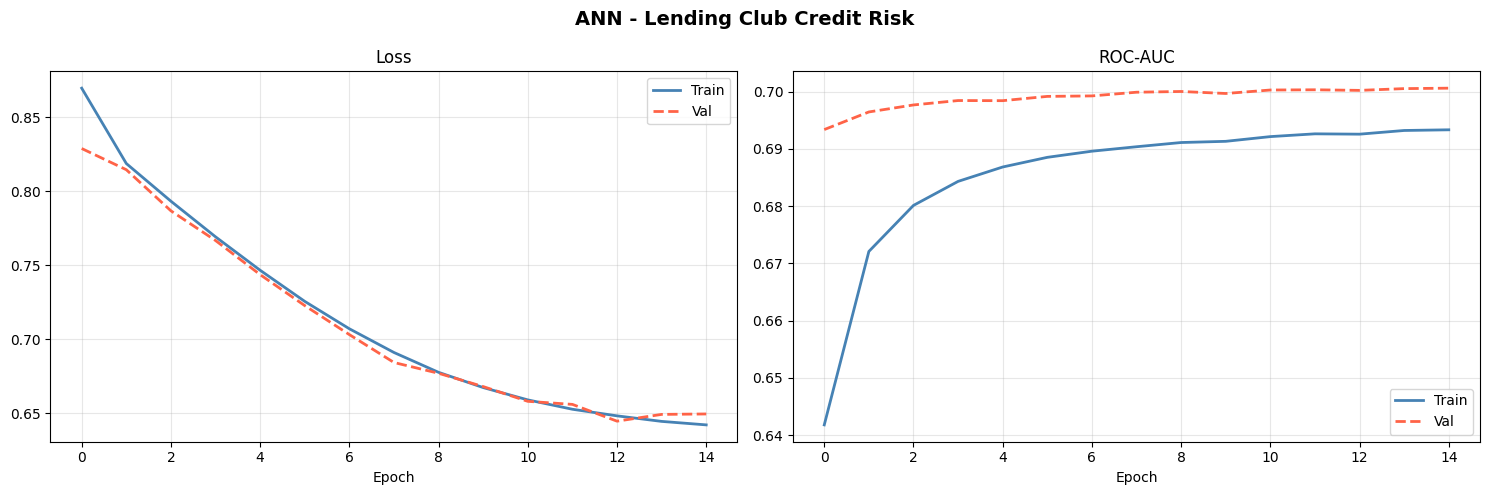

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score


def evaluate_nn(true, pred, train=True):
    label = 'Train' if train else 'Test'
    print(f'\n{label} Result  ================================================')
    print(f'Accuracy : {accuracy_score(true, pred)*100:.2f}%')
    print(pd.DataFrame(classification_report(true, pred, output_dict=True)))
    print(f'Confusion Matrix:\n{confusion_matrix(true, pred)}')


def plot_learning_evolution(r):
    auc_key = 'AUC' if 'AUC' in r.history else 'auc'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('ANN - Lending Club Credit Risk', fontsize=14, fontweight='bold')

    ax1.plot(r.history['loss'],     label='Train', lw=2, color='steelblue')
    ax1.plot(r.history['val_loss'], label='Val',   lw=2, color='tomato', ls='--')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(r.history[auc_key],           label='Train', lw=2, color='steelblue')
    ax2.plot(r.history[f'val_{auc_key}'],  label='Val',   lw=2, color='tomato', ls='--')
    ax2.set_title('ROC-AUC'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()


def build_model(n_features, hidden_units, dropout_rates, lr):
    inp = Input(shape=(n_features,))
    x = BatchNormalization()(inp)
    x = Dropout(dropout_rates[0])(x)
    for i, units in enumerate(hidden_units):
        x = Dense(units, activation='relu', kernel_initializer='he_normal',
                  kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rates[i + 1])(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=[AUC(name='AUC')])
    return model


# Target encoding
bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']
y_train_binary = np.isin(y_train, bad_statuses).astype(np.float32)
y_test_binary  = np.isin(y_test,  bad_statuses).astype(np.float32)

# Feature scaling  (fix: original fed raw values -> model predicted only majority class)
for _df in [X_train, X_test]:
    if _df['term'].dtype == object:
        _df['term'] = _df['term'].str.replace(' months', '', regex=False).astype(float)

X_train_num    = X_train.select_dtypes(include=[np.number])
X_test_num     = X_test.select_dtypes(include=[np.number])
scaler_ann     = StandardScaler()
X_train_scaled = scaler_ann.fit_transform(X_train_num).astype(np.float32)
X_test_scaled  = scaler_ann.transform(X_test_num).astype(np.float32)
print(f'Features: {X_train_scaled.shape[1]}  Train: {X_train_scaled.shape[0]:,}  Test: {X_test_scaled.shape[0]:,}')
print(f'Bad-loan rate: {y_train_binary.mean()*100:.1f}%')

# Class weights
neg, pos      = float((y_train_binary == 0).sum()), float((y_train_binary == 1).sum())
total_n       = neg + pos
class_weights = {0: (1/neg)*(total_n/2), 1: (1/pos)*(total_n/2)}

# Architecture: 4-layer pyramid [512, 256, 128, 64] + pyramid dropout
hidden_units  = [512, 256, 128, 64]
dropout_rates = [0.05, 0.4, 0.3, 0.2, 0.1]   # len = 5 = 4 layers + 1

model = build_model(
    n_features    = X_train_scaled.shape[1],
    hidden_units  = hidden_units,
    dropout_rates = dropout_rates,
    lr            = 3e-4,
)
model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_AUC', mode='max', patience=6,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_AUC', mode='max', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1)

# Train
r = model.fit(
    X_train_scaled, y_train_binary,
    validation_data = (X_test_scaled, y_test_binary),
    epochs          = 15,
    batch_size      = 4096,
    callbacks       = [early_stop, reduce_lr],
    class_weight    = class_weights,
    verbose         = 1,
)

plot_learning_evolution(r)


In [53]:
y_train_prob = model.predict(X_train_scaled, batch_size=4096).flatten()
y_test_prob  = model.predict(X_test_scaled,  batch_size=4096).flatten()

threshold    = 0.57
y_train_pred = (y_train_prob >= threshold).astype(int)
y_test_pred  = (y_test_prob  >= threshold).astype(int)

evaluate_nn(y_train_binary.astype(int), y_train_pred, train=True)
evaluate_nn(y_test_binary.astype(int),  y_test_pred,  train=False)

train_auc = roc_auc_score(y_train_binary, y_train_prob)
test_auc  = roc_auc_score(y_test_binary,  y_test_prob)
print(f'ROC-AUC -> Train: {train_auc:.4f}  |  Test: {test_auc:.4f}')

# Find best threshold by bad-loan F1
from sklearn.metrics import f1_score
thresholds = np.arange(0.10, 0.90, 0.05)
f1s    = [f1_score(y_test_binary.astype(int), (y_test_prob >= t).astype(int), pos_label=1) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print(f'Best threshold (bad-loan F1): {best_t:.2f}  F1={max(f1s):.4f}')


401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Train Result  ================================================
Accuracy : 71.25%
                      0              1  accuracy     macro avg  weighted avg
precision  9.142496e-01       0.230550  0.712539  5.723998e-01  8.264145e-01
recall     7.395278e-01       0.529451  0.712539  6.344892e-01  7.125391e-01
f1-score   8.176590e-01       0.321223  0.712539  5.694410e-01  7.538817e-01
support    1.430928e+06  210930.000000  0.712539  1.641858e+06  1.641858e+06
Confusion Matrix:
[[1058211  372717]
 [  99253  111677]]

Test Result  ================================================
Accuracy : 71.48%
                       0             1  accuracy      macro avg   weighted avg
precision       0.914650      0.231677  0.714764       0.573164       0.827109
recall          0.742075      0.529000  0.714764       0.635538       0.714764
f1-score        0.819374      0.322232  0.714764       0.570803       0.755653

# XGBoost

scale_pos_weight: 6.78  (neg=1,430,928 / pos=210,930)
[0]	validation_0-auc:0.69802	validation_1-auc:0.69739
[50]	validation_0-auc:0.71950	validation_1-auc:0.71818
[100]	validation_0-auc:0.72615	validation_1-auc:0.72363
[150]	validation_0-auc:0.72866	validation_1-auc:0.72506
[200]	validation_0-auc:0.73089	validation_1-auc:0.72618
[250]	validation_0-auc:0.73406	validation_1-auc:0.72833
[300]	validation_0-auc:0.73640	validation_1-auc:0.72980
[350]	validation_0-auc:0.73845	validation_1-auc:0.73103
[400]	validation_0-auc:0.74012	validation_1-auc:0.73175
[450]	validation_0-auc:0.74154	validation_1-auc:0.73225
[500]	validation_0-auc:0.74293	validation_1-auc:0.73276
[550]	validation_0-auc:0.74403	validation_1-auc:0.73296
[600]	validation_0-auc:0.74525	validation_1-auc:0.73323
[650]	validation_0-auc:0.74640	validation_1-auc:0.73343
[700]	validation_0-auc:0.74739	validation_1-auc:0.73346
[750]	validation_0-auc:0.74833	validation_1-auc:0.73359
[800]	validation_0-auc:0.74934	validation_1-auc:0.733

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:774: UserWarning: [20:59:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best threshold (bad-loan F1): 0.55  F1=0.3468

Train Result  ================================================
Accuracy : 70.55%
                    0.0            1.0  accuracy     macro avg  weighted avg
precision  9.310086e-01       0.248886  0.705477  5.899473e-01  8.433761e-01
recall     7.150500e-01       0.640535  0.705477  6.777924e-01  7.054770e-01
f1-score   8.088627e-01       0.358481  0.705477  5.836717e-01  7.510020e-01
support    1.430928e+06  210930.000000  0.705477  1.641858e+06  1.641858e+06
Confusion Matrix:
[[1023185  407743]
 [  75822  135108]]

Test Result  ================================================
Accuracy : 70.25%
                     0.0           1.0  accuracy      macro avg   weighted avg
precision       0.926854      0.241294  0.702491       0.584074       0.838982
recall          0.715193      0.616093  0.702491       0.665643       0.702491
f1-score        0.807382      0.346774  0.702491       0.577078       0.748343
support    257645.000000  37879.0

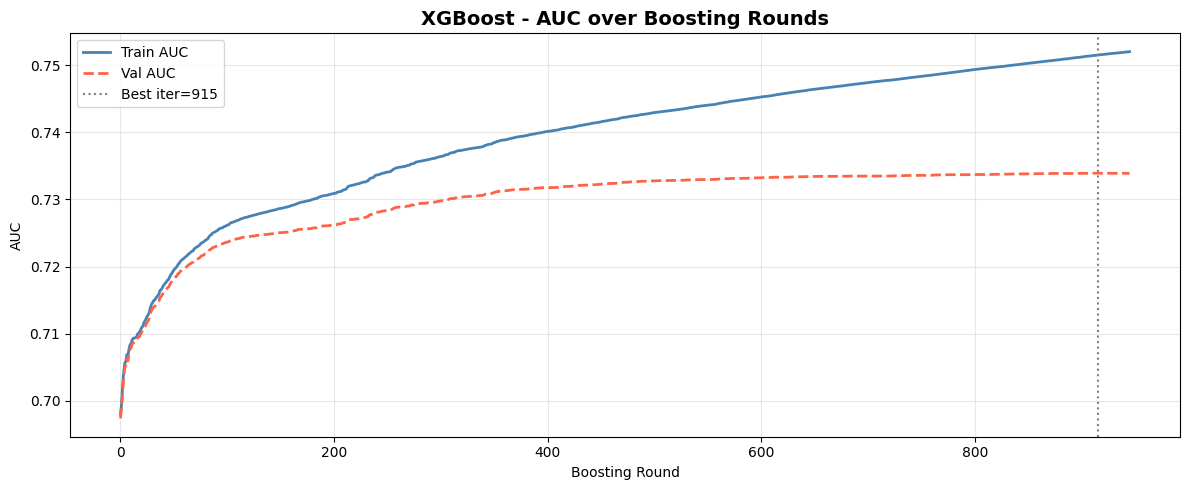

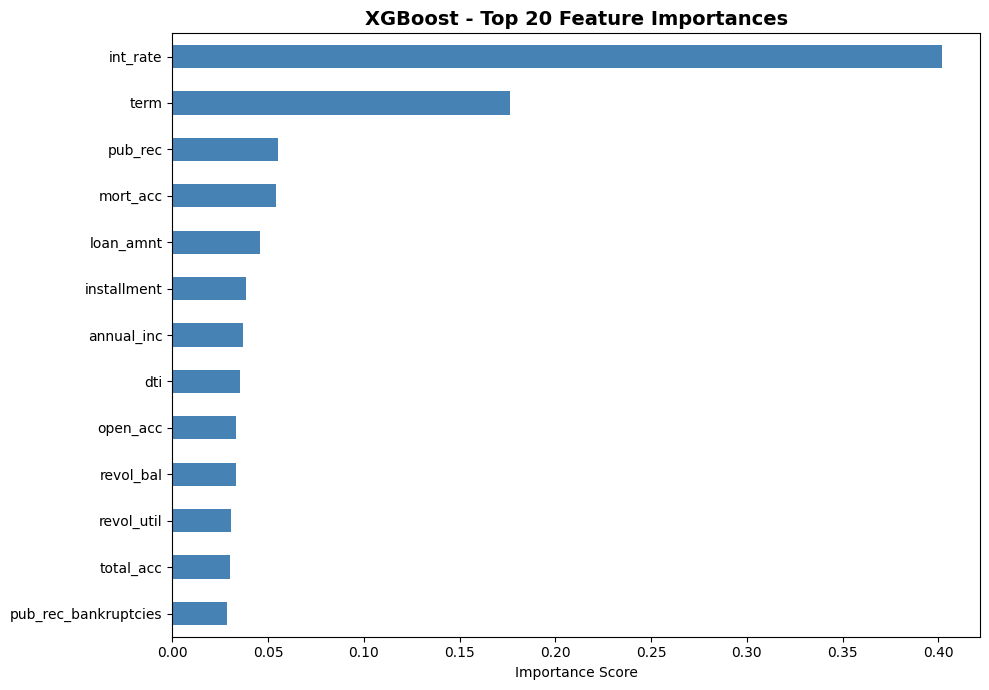

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score,
)

bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']

for _df in [X_train, X_test]:
    if _df['term'].dtype == object:
        _df['term'] = _df['term'].str.replace(' months', '', regex=False).astype(float)

X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num  = X_test.select_dtypes(include=[np.number])

y_train_binary = np.isin(y_train, bad_statuses).astype(np.float32)
y_test_binary  = np.isin(y_test,  bad_statuses).astype(np.float32)

neg = float((y_train_binary == 0).sum())
pos = float((y_train_binary == 1).sum())
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg:,.0f} / pos={pos:,.0f})')

xgb_model = xgb.XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 10,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    gamma                 = 1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos_weight,
    objective             = 'binary:logistic',
    eval_metric           = 'auc',
    tree_method           = 'hist',
    device                = 'cuda',       
    early_stopping_rounds = 30,           
    random_state          = 42,
    n_jobs                = -1,
)

xgb_model.fit(
    X_train_num, y_train_binary,
    eval_set = [(X_train_num, y_train_binary),
                (X_test_num,  y_test_binary)],
    verbose  = 50,
)

y_train_prob_xgb = xgb_model.predict_proba(X_train_num)[:, 1]
y_test_prob_xgb  = xgb_model.predict_proba(X_test_num)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.05)
f1s    = [f1_score(y_test_binary, (y_test_prob_xgb >= t).astype(int), pos_label=1) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print(f'Best threshold (bad-loan F1): {best_t:.2f}  F1={max(f1s):.4f}')

y_train_pred_xgb = (y_train_prob_xgb >= best_t).astype(int)
y_test_pred_xgb  = (y_test_prob_xgb  >= best_t).astype(int)

for true, pred, label in [
    (y_train_binary, y_train_pred_xgb, 'Train'),
    (y_test_binary,  y_test_pred_xgb,  'Test'),
]:
    print(f'\n{label} Result  ================================================')
    print(f'Accuracy : {accuracy_score(true, pred)*100:.2f}%')
    print(pd.DataFrame(classification_report(true, pred, output_dict=True)))
    print(f'Confusion Matrix:\n{confusion_matrix(true, pred)}')

train_auc = roc_auc_score(y_train_binary, y_train_prob_xgb)
test_auc  = roc_auc_score(y_test_binary,  y_test_prob_xgb)
print(f'\nROC-AUC -> Train: {train_auc:.4f}  |  Test: {test_auc:.4f}')

# Learning curve 
results = xgb_model.evals_result()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results['validation_0']['auc'], label='Train AUC', lw=2, color='steelblue')
ax.plot(results['validation_1']['auc'], label='Val AUC',   lw=2, color='tomato', ls='--')
ax.axvline(xgb_model.best_iteration, color='gray', ls=':', label=f'Best iter={xgb_model.best_iteration}')
ax.set_title('XGBoost - AUC over Boosting Rounds', fontsize=14, fontweight='bold')
ax.set_xlabel('Boosting Round'); ax.set_ylabel('AUC')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train_num.columns)
top20    = feat_imp.nlargest(20).sort_values()
fig, ax  = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost - Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()
